# Notebook 3 — Visual Feature Extraction
### Multimodal Driving Risk Prediction | MSc Business Analytics | Dublin Business School

---

## What This Notebook Does
Extracts four types of visual features from the middle frame of each clip's front camera footage.
This is the most computationally intensive notebook — GPU acceleration recommended.
Frame extraction is resumable so interrupted sessions can continue without reprocessing.

## Key Steps
1. **Extract** middle frame from front-wide-120fov camera for each clip (resumable)
2. **Compute** brightness and contrast using OpenCV
3. **Detect** objects using YOLOv8x — counts across 8 categories
4. **Extract** CNN embeddings using ResNet-50 → reduce to 10 PCA components
5. **Extract** ViT embeddings using ViT-B/16 → reduce to 10 independent PCA components
6. **Check** coverage — confirm all four modalities cover the same clips
7. **Merge** all visual features on `clip_id` and save

## Features Extracted (31 total)
| Modality | Features | Count |
|---|---|---|
| Basic Visual | `brightness`, `contrast` | 2 |
| YOLOv8 Object Detection | `person_count`, `car_count`, `truck_count`, `bus_count`, `motorcycle_count`, `bicycle_count`, `traffic_light_count`, `stop_sign_count`, `total_objects` | 9 |
| ResNet-50 CNN (PCA) | `cnn_feature_0` to `cnn_feature_9` | 10 |
| ViT-B/16 (PCA) | `vit_feature_0` to `vit_feature_9` | 10 |

## Input
- `prepared_dataset_2000.csv` — from Notebook 1
- Front camera frames downloaded from Hugging Face

## Output
- `visual_features_final.csv` — 1,899 clips × 31 visual features

## Next Notebook
→ **Notebook 4** merges all features from Notebooks 1, 2, and 3 into the final dataset

In [ ]:
# ============================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ============================================================
# PURPOSE:Set up environment for visual feature extraction.
# OUTPUT:Required computer vision and ML libraries installed.

!pip install -q huggingface_hub pandas==2.2.2 pyarrow opencv-python ultralytics torch torchvision scikit-learn

# ------------------------------------------------------------
# VERIFY INSTALLATION
# ------------------------------------------------------------
import pandas as pd

print("Libraries installed successfully.\n")

print("Installed pandas version:")
print(pd.__version__)

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 1 complete: Required visual processing libraries installed.")
print("------------------------------------------------------------")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00
Libraries installed successfully.

Installed pandas version:
2.2.2

------------------------------------------------------------
Step 1 complete: Required visual processing libraries installed.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 2: AUTHENTICATE DATA ACCESS
# ============================================================
# PURPOSE:Enable access to the gated NVIDIA AV dataset.
# OUTPUT:Authenticated session for dataset download.

from huggingface_hub import login

login()

# ------------------------------------------------------------
# VERIFY AUTHENTICATION
# ------------------------------------------------------------
print("Login successful. Your Colab notebook is now connected to Hugging Face.")

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 2 complete: Hugging Face authentication successful.")
print("------------------------------------------------------------")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Login successful. Your Colab notebook is now connected to Hugging Face.

------------------------------------------------------------
Step 2 complete: Hugging Face authentication successful.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 3: IMPORT REQUIRED LIBRARIES
# ============================================================
# PURPOSE:Load libraries for image processing, YOLO, CNN features, and dataset handling.
# OUTPUT:All required visual processing libraries imported and verified.

import os
import zipfile
import tempfile
import shutil
import glob

import cv2
import numpy as np
import pandas as pd

from google.colab import drive
from huggingface_hub import hf_hub_download

from ultralytics import YOLO

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# VERIFY IMPORTS
# ------------------------------------------------------------
print("Libraries imported successfully.\n")

print("Pandas version:")
print(pd.__version__)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 2 complete: Visual processing libraries imported.")
print("------------------------------------------------------------")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.

Pandas version:
2.2.2

PyTorch version:
2.10.0+cu128

CUDA available:
True

------------------------------------------------------------
Step 2 complete: Visual processing libraries imported.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 4: MOUNT GOOGLE DRIVE AND LOAD PREPARED DATASET
# ============================================================
# PURPOSE:Load the prepared clip list created in Notebook 1.
# OUTPUT:Prepared dataset loaded for visual feature extraction.

# ------------------------------------------------------------
# MOUNT GOOGLE DRIVE
# ------------------------------------------------------------
drive.mount("/content/drive")

# ------------------------------------------------------------
# DEFINE INPUT FILE PATH
# ------------------------------------------------------------
base_path = "/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab"
input_path = f"{base_path}/01_data_preparation/prepared_dataset_2000.csv"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------
prepared_dataset = pd.read_csv(input_path)

# ------------------------------------------------------------
# VERIFY LOADED DATASET
# ------------------------------------------------------------
print("Prepared dataset loaded successfully.\n")

print("Input file path:")
print(input_path)

print("\nPrepared dataset shape:")
print(prepared_dataset.shape)

print("\nUnique chunks:")
print(prepared_dataset["chunk"].nunique())

print("\nScenario type distribution:")
print(prepared_dataset["scenario_type"].value_counts())

print("\nFirst 5 rows:")
display(prepared_dataset.head())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 3 complete: Prepared dataset loaded for visual extraction.")
print("------------------------------------------------------------")

Mounted at /content/drive
Prepared dataset loaded successfully.

Input file path:
/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab/01_data_preparation/prepared_dataset_2000.csv

Prepared dataset shape:
(2000, 16)

Unique chunks:
150

Scenario type distribution:
scenario_type
normal    1000
rare      1000
Name: count, dtype: int64

First 5 rows:



------------------------------------------------------------
Step 3 complete: Prepared dataset loaded for visual extraction.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 5: IDENTIFY REQUIRED CAMERA CHUNKS
# ============================================================
# PURPOSE:Determine which camera chunks are needed for selected clips.
# OUTPUT:List of unique camera chunk IDs for efficient download.

# ------------------------------------------------------------
# EXTRACT UNIQUE CHUNK NUMBERS
# ------------------------------------------------------------
required_chunks = sorted(prepared_dataset["chunk"].unique())

# ------------------------------------------------------------
# PRINT CHUNK INFORMATION
# ------------------------------------------------------------
print("Required camera chunks identified successfully.\n")

print("Total unique chunks needed:")
print(len(required_chunks))

print("\nFirst 10 chunk IDs:")
print(required_chunks[:10])

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 4 complete: Required camera chunks identified.")
print("------------------------------------------------------------")

Required camera chunks identified successfully.

Total unique chunks needed:
150

First 10 chunk IDs:
[np.int64(3), np.int64(8), np.int64(12), np.int64(14), np.int64(30), np.int64(42), np.int64(44), np.int64(45), np.int64(53), np.int64(60)]

------------------------------------------------------------
Step 4 complete: Required camera chunks identified.
------------------------------------------------------------


In [1]:
# ============================================================
# STEP 6: EXTRACT MIDDLE FRAMES FROM FRONT-WIDE CAMERA
# ============================================================
# PURPOSE:Extract one representative frame per clip using resumable chunk processing.
# OUTPUT:Frame images and extraction logs saved to Google Drive.

# ------------------------------------------------------------
# CAMERA CONFIGURATION
# ------------------------------------------------------------
camera_name = "camera_front_wide_120fov"
repo_id = "nvidia/PhysicalAI-Autonomous-Vehicles"

# ------------------------------------------------------------
# CREATE OUTPUT FOLDERS
# ------------------------------------------------------------
base_path = "/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab"
notebook3_path = f"{base_path}/03_visual_features"
frames_path = f"{notebook3_path}/frames_front_wide"

os.makedirs(notebook3_path, exist_ok=True)
os.makedirs(frames_path, exist_ok=True)

# ------------------------------------------------------------
# CREATE CLIP LOOKUP
# ------------------------------------------------------------
selected_clips = prepared_dataset[["clip_id", "chunk"]].copy()
selected_clips["clip_id"] = selected_clips["clip_id"].astype(str)

clip_lookup = selected_clips.groupby("chunk")["clip_id"].apply(set).to_dict()

# ------------------------------------------------------------
# FRAME EXTRACTION FUNCTION
# ------------------------------------------------------------
def extract_middle_frame(video_path, output_image_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return False

    middle_frame_index = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_index)

    success, frame = cap.read()
    cap.release()

    if success:
        cv2.imwrite(output_image_path, frame)
        return True

    return False

# ------------------------------------------------------------
# PROCESS CHUNKS ONE BY ONE
# ------------------------------------------------------------
frame_results = []
failed_chunks = []

total_chunks = len(required_chunks)

for chunk_index, chunk_id in enumerate(required_chunks):

    chunk_id = int(chunk_id)
    chunk_str = f"{chunk_id:04d}"

    zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

    print("\n------------------------------------------------------------")
    print(f"Processing chunk {chunk_index + 1} / {total_chunks}: {zip_filename}")
    print("------------------------------------------------------------")

    target_clip_ids = clip_lookup.get(chunk_id, set())

    # Skip clips that already have saved frames
    target_clip_ids = {
        clip_id for clip_id in target_clip_ids
        if not os.path.exists(os.path.join(frames_path, f"{clip_id}_middle.jpg"))
    }

    if len(target_clip_ids) == 0:
        print("All frames from this chunk already exist. Skipping chunk.")
        continue

    temp_dir = tempfile.mkdtemp()

    try:
        zip_local_path = hf_hub_download(
            repo_id=repo_id,
            filename=zip_filename,
            repo_type="dataset",
            resume_download=True
        )

        with zipfile.ZipFile(zip_local_path, "r") as zip_ref:
            zip_members = zip_ref.namelist()

            for clip_id in target_clip_ids:
                target_video_name = f"{clip_id}.{camera_name}.mp4"

                matching_files = [
                    member for member in zip_members
                    if target_video_name in member
                ]

                if len(matching_files) == 0:
                    frame_results.append({
                        "clip_id": clip_id,
                        "chunk": chunk_id,
                        "frame_path": None,
                        "frame_extracted": False,
                        "error": "Video not found in ZIP"
                    })
                    continue

                video_member = matching_files[0]
                zip_ref.extract(video_member, temp_dir)

                extracted_video_path = os.path.join(temp_dir, video_member)
                output_image_path = os.path.join(frames_path, f"{clip_id}_middle.jpg")

                success = extract_middle_frame(extracted_video_path, output_image_path)

                frame_results.append({
                    "clip_id": clip_id,
                    "chunk": chunk_id,
                    "frame_path": output_image_path if success else None,
                    "frame_extracted": success,
                    "error": None if success else "Frame extraction failed"
                })

                # Delete extracted video immediately after frame extraction
                if os.path.exists(extracted_video_path):
                    os.remove(extracted_video_path)

        print(f"Chunk completed successfully. Frames processed: {len(target_clip_ids)}")

    except Exception as e:
        print("Chunk failed. Error:")
        print(e)

        failed_chunks.append({
            "chunk": chunk_id,
            "zip_filename": zip_filename,
            "error": str(e)
        })

        for clip_id in target_clip_ids:
            frame_results.append({
                "clip_id": clip_id,
                "chunk": chunk_id,
                "frame_path": None,
                "frame_extracted": False,
                "error": str(e)
            })

    finally:
        shutil.rmtree(temp_dir, ignore_errors=True)

    # Save progress every 5 chunks
    if (chunk_index + 1) % 5 == 0:
        progress_log_path = f"{notebook3_path}/frame_extraction_log_progress.csv"
        pd.DataFrame(frame_results).to_csv(progress_log_path, index=False)
        print(f"Progress saved at: {progress_log_path}")

# ------------------------------------------------------------
# CREATE FINAL LOGS
# ------------------------------------------------------------
frame_results_df = pd.DataFrame(frame_results)
failed_chunks_df = pd.DataFrame(failed_chunks)

frame_log_path = f"{notebook3_path}/frame_extraction_log.csv"
failed_chunks_path = f"{notebook3_path}/failed_camera_chunks.csv"

frame_results_df.to_csv(frame_log_path, index=False)
failed_chunks_df.to_csv(failed_chunks_path, index=False)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\nFrame extraction completed.\n")

print("Frame extraction log shape:")
print(frame_results_df.shape)

print("\nExtraction status:")
print(frame_results_df["frame_extracted"].value_counts())

print("\nFailed chunks:")
print(len(failed_chunks_df))

print("\nFrame log saved at:")
print(frame_log_path)

print("\nFailed chunks log saved at:")
print(failed_chunks_path)

print("\nFirst 5 rows:")
display(frame_results_df.head())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 6 complete: Resumable frame extraction finished.")
print("------------------------------------------------------------")

NameError: name 'os' is not defined

In [ ]:
# ============================================================
# STEP 6A: REBUILD FRAME LOG FROM SAVED FRAME FOLDER
# ============================================================
# PURPOSE:Create a complete frame log directly from saved image files.
# OUTPUT:Updated frame log containing all extracted frames.

import os
import pandas as pd

# ------------------------------------------------------------
# REBUILD FRAME RECORDS FROM FRAME FOLDER
# ------------------------------------------------------------
frame_records = []

jpg_files = [
    file for file in os.listdir(frames_path)
    if file.endswith("_middle.jpg")
]

for file in jpg_files:
    clip_id = file.replace("_middle.jpg", "")
    frame_path = os.path.join(frames_path, file)

    frame_records.append({
        "clip_id": clip_id,
        "frame_path": frame_path,
        "frame_extracted": True
    })

frame_df = pd.DataFrame(frame_records)

# ------------------------------------------------------------
# SAVE UPDATED FRAME LOG
# ------------------------------------------------------------
frame_log_path = f"{notebook3_path}/frame_extraction_log_rebuilt.csv"
frame_df.to_csv(frame_log_path, index=False)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("Frame log rebuilt successfully.\n")

print("Number of image files found:")
print(len(jpg_files))

print("\nRebuilt frame log shape:")
print(frame_df.shape)

print("\nFirst 5 rows:")
display(frame_df.head())

print("\nUpdated frame log saved at:")
print(frame_log_path)

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 6A complete: Frame log rebuilt from saved image folder.")
print("------------------------------------------------------------")

Frame log rebuilt successfully.

Number of image files found:
1899

Rebuilt frame log shape:
(1899, 3)

First 5 rows:



Updated frame log saved at:
/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab/03_visual_features/frame_extraction_log_rebuilt.csv

------------------------------------------------------------
Step 6A complete: Frame log rebuilt from saved image folder.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 7: EXTRACT BASIC IMAGE FEATURES (BRIGHTNESS + CONTRAST)
# ============================================================
# PURPOSE:Compute brightness and contrast from all extracted frames.
# OUTPUT:Visual features dataset for all clips with frames.

import cv2
import pandas as pd

# ------------------------------------------------------------
# LOAD REBUILT FRAME LOG
# ------------------------------------------------------------
frame_log_path = f"{notebook3_path}/frame_extraction_log_rebuilt.csv"
frame_df = pd.read_csv(frame_log_path)

print("Frame log loaded.\n")

print("Total frames available:")
print(frame_df.shape)

# ------------------------------------------------------------
# FEATURE EXTRACTION
# ------------------------------------------------------------
visual_features = []

for i, row in frame_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    try:
        image = cv2.imread(frame_path)

        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        brightness = gray.mean()
        contrast = gray.std()

        visual_features.append({
            "clip_id": clip_id,
            "brightness": brightness,
            "contrast": contrast
        })

    except Exception as e:
        print(f"Error processing {clip_id}: {e}")

    # Progress print
    if (i + 1) % 200 == 0:
        print(f"Processed {i + 1} / {len(frame_df)} frames")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
visual_features_df = pd.DataFrame(visual_features)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\nBrightness and contrast extraction completed.\n")

print("Visual features shape:")
print(visual_features_df.shape)

print("\nFirst 5 rows:")
display(visual_features_df.head())

print("\nSummary statistics:")
display(visual_features_df.describe())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 7 complete: Brightness and contrast features extracted.")
print("------------------------------------------------------------")

Frame log loaded.

Total frames available:
(1899, 3)
Processed 200 / 1899 frames
Processed 400 / 1899 frames
Processed 600 / 1899 frames
Processed 800 / 1899 frames
Processed 1000 / 1899 frames
Processed 1200 / 1899 frames
Processed 1400 / 1899 frames
Processed 1600 / 1899 frames
Processed 1800 / 1899 frames

Brightness and contrast extraction completed.

Visual features shape:
(1899, 3)

First 5 rows:



Summary statistics:



------------------------------------------------------------
Step 7 complete: Brightness and contrast features extracted.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 8: EXTRACT YOLO OBJECT FEATURES
# ============================================================
# PURPOSE:Detect important objects in each frame.
# OUTPUT:Object count features per clip.

from ultralytics import YOLO
import pandas as pd

# ------------------------------------------------------------
# LOAD YOLO MODEL (LIGHTWEIGHT)
# ------------------------------------------------------------
yolo_model = YOLO("yolov8x.pt")

# ------------------------------------------------------------
# IMPORTANT CLASSES
# ------------------------------------------------------------
important_classes = [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "bus",
    "truck",
    "traffic light",
    "stop sign"
]

# ------------------------------------------------------------
# LOAD FRAME DATA
# ------------------------------------------------------------
frame_df = pd.read_csv(f"{notebook3_path}/frame_extraction_log_rebuilt.csv")

# ------------------------------------------------------------
# PROCESS FRAMES
# ------------------------------------------------------------
yolo_features = []

for i, row in frame_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    counts = {
        "clip_id": clip_id,
        "person_count": 0,
        "bicycle_count": 0,
        "car_count": 0,
        "motorcycle_count": 0,
        "bus_count": 0,
        "truck_count": 0,
        "traffic_light_count": 0,
        "stop_sign_count": 0,
        "total_objects": 0
    }

    try:
        results = yolo_model(frame_path, verbose=False)

        for box in results[0].boxes:
            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]

            if class_name in important_classes:
                column_name = class_name.replace(" ", "_") + "_count"
                counts[column_name] += 1
                counts["total_objects"] += 1

    except Exception as e:
        print(f"Error on {clip_id}: {e}")

    yolo_features.append(counts)

    # Progress tracking
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} / {len(frame_df)} frames")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
yolo_features_df = pd.DataFrame(yolo_features)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\nYOLO extraction completed.\n")

print("YOLO features shape:")
print(yolo_features_df.shape)

print("\nFirst 5 rows:")
display(yolo_features_df.head())

print("\nSummary:")
display(yolo_features_df.describe())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 8 complete: YOLO object features extracted.")
print("------------------------------------------------------------")

Processed 100 / 1899 frames
Processed 200 / 1899 frames
Processed 300 / 1899 frames
Processed 400 / 1899 frames
Processed 500 / 1899 frames
Processed 600 / 1899 frames
Processed 700 / 1899 frames
Processed 800 / 1899 frames
Processed 900 / 1899 frames
Processed 1000 / 1899 frames
Processed 1100 / 1899 frames
Processed 1200 / 1899 frames
Processed 1300 / 1899 frames
Processed 1400 / 1899 frames
Processed 1500 / 1899 frames
Processed 1600 / 1899 frames
Processed 1700 / 1899 frames
Processed 1800 / 1899 frames

YOLO extraction completed.

YOLO features shape:
(1899, 10)

First 5 rows:



Summary:



------------------------------------------------------------
Step 8 complete: YOLO object features extracted.
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Processed 200 / 1899 frames
Processed 400 / 1899 frames
Processed 600 / 1899 frames
Processed 800 / 1899 frames
Processed 1000 / 1899 frames
Processed 1200 / 1899 frames
Processed 1400 / 1899 frames
Processed 1600 / 1899 frames
Processed 1800 / 1899 frames
Raw CNN feature shape: (1899, 2048)

CNN PCA - Explained Variance per Component:
[     0.0792      0.0575      0.0506       0.042      0.0341      0.0271      0.0223      0.0213      0.0188      0.0169]

CNN PCA - Cumulative Explained Variance (10 components):
0.3699


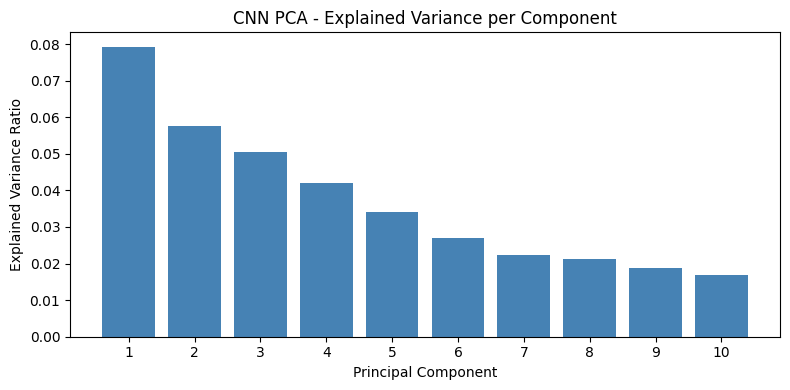


CNN feature extraction completed.

CNN features shape:
(1899, 11)

First 5 rows:



------------------------------------------------------------
Step 9 complete: CNN features extracted, reduced, and variance validated.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 9: EXTRACT CNN FEATURES (RESNET + PCA)
# ============================================================
# PURPOSE:Generate high-level visual embeddings and reduce dimensionality.
#         PCA explained variance is reported to validate component selection.
# OUTPUT:Compact CNN feature set per clip with variance diagnostics.

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD PRETRAINED RESNET (REMOVE CLASSIFIER)
# ------------------------------------------------------------
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])  # remove final layer
resnet.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet.to(device)

# ------------------------------------------------------------
# IMAGE TRANSFORM
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ------------------------------------------------------------
# LOAD FRAME DATA
# ------------------------------------------------------------
frame_df = pd.read_csv(f"{notebook3_path}/frame_extraction_log_rebuilt.csv")

# ------------------------------------------------------------
# EXTRACT FEATURES
# ------------------------------------------------------------
features_list = []
clip_ids = []

for i, row in frame_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    try:
        image = Image.open(frame_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            features = resnet(image).cpu().numpy().flatten()

        features_list.append(features)
        clip_ids.append(clip_id)

    except Exception as e:
        print(f"Error on {clip_id}: {e}")

    if (i + 1) % 200 == 0:
        print(f"Processed {i + 1} / {len(frame_df)} frames")

# ------------------------------------------------------------
# CONVERT TO ARRAY
# ------------------------------------------------------------
features_array = np.array(features_list)

print("Raw CNN feature shape:", features_array.shape)

# ------------------------------------------------------------
# STANDARDIZE + PCA
# ------------------------------------------------------------
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

pca = PCA(n_components=10)  # reduce to 10 features
features_pca = pca.fit_transform(features_scaled)

# ------------------------------------------------------------
# PCA EXPLAINED VARIANCE DIAGNOSTIC
# ------------------------------------------------------------
print("\nCNN PCA - Explained Variance per Component:")
print(np.round(pca.explained_variance_ratio_, 4))

print("\nCNN PCA - Cumulative Explained Variance (10 components):")
print(round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("CNN PCA - Explained Variance per Component")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
cnn_features_df = pd.DataFrame(
    features_pca,
    columns=[f"cnn_feature_{i}" for i in range(10)]
)
cnn_features_df["clip_id"] = clip_ids

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\nCNN feature extraction completed.\n")

print("CNN features shape:")
print(cnn_features_df.shape)

print("\nFirst 5 rows:")
display(cnn_features_df.head())

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 9 complete: CNN features extracted, reduced, and variance validated.")
print("------------------------------------------------------------")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 189MB/s]


Processed 200 / 1899 frames
Processed 400 / 1899 frames
Processed 600 / 1899 frames
Processed 800 / 1899 frames
Processed 1000 / 1899 frames
Processed 1200 / 1899 frames
Processed 1400 / 1899 frames
Processed 1600 / 1899 frames
Processed 1800 / 1899 frames

ViT PCA - Explained Variance per Component:
[     0.0941      0.0574      0.0437      0.0348      0.0313      0.0274      0.0236      0.0188      0.0171      0.0155]

ViT PCA - Cumulative Explained Variance (10 components):
0.3637


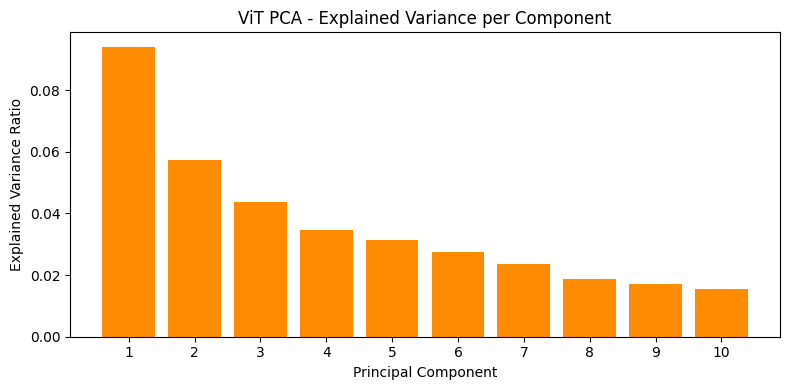

ViT features shape: (1899, 11)

First 5 rows:



------------------------------------------------------------
Step 10 complete: ViT features extracted, reduced, and variance validated.
------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 10: EXTRACT VIT (TRANSFORMER) FEATURES
# ============================================================
# PURPOSE:Generate transformer-based visual embeddings.
#         PCA explained variance is reported to validate component selection.
# OUTPUT:ViT feature set per clip with variance diagnostics.

import torch
import torchvision.transforms as transforms
from torchvision.models import vit_b_16
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD VIT MODEL
# ------------------------------------------------------------
vit = vit_b_16(weights="DEFAULT")
vit.heads = torch.nn.Identity()  # remove classifier
vit.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit.to(device)

# ------------------------------------------------------------
# IMAGE TRANSFORM
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# ------------------------------------------------------------
# LOAD FRAME DATA
# ------------------------------------------------------------
frame_df = pd.read_csv(f"{notebook3_path}/frame_extraction_log_rebuilt.csv")

# ------------------------------------------------------------
# EXTRACT FEATURES
# ------------------------------------------------------------
features_list = []
clip_ids = []

for i, row in frame_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    try:
        image = Image.open(frame_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            features = vit(image).cpu().numpy().flatten()

        features_list.append(features)
        clip_ids.append(clip_id)

    except Exception as e:
        print(f"Error on {clip_id}: {e}")

    if (i + 1) % 200 == 0:
        print(f"Processed {i + 1} / {len(frame_df)} frames")

# ------------------------------------------------------------
# PCA REDUCTION
# ------------------------------------------------------------
features_array = np.array(features_list)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

pca = PCA(n_components=10)
features_pca = pca.fit_transform(features_scaled)

# ------------------------------------------------------------
# PCA EXPLAINED VARIANCE DIAGNOSTIC
# ------------------------------------------------------------
print("\nViT PCA - Explained Variance per Component:")
print(np.round(pca.explained_variance_ratio_, 4))

print("\nViT PCA - Cumulative Explained Variance (10 components):")
print(round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_, color="darkorange")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("ViT PCA - Explained Variance per Component")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
vit_features_df = pd.DataFrame(
    features_pca,
    columns=[f"vit_feature_{i}" for i in range(10)]
)
vit_features_df["clip_id"] = clip_ids

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("ViT features shape:", vit_features_df.shape)

print("\nFirst 5 rows:")
display(vit_features_df.head())

print("\n------------------------------------------------------------")
print("Step 10 complete: ViT features extracted, reduced, and variance validated.")
print("------------------------------------------------------------")

In [ ]:
# ============================================================
# STEP 11: MERGE ALL VISUAL FEATURES
# ============================================================
# PURPOSE:Combine all visual features into a single dataset.
#         Coverage check ensures all modalities cover the same clips.
# OUTPUT:Final visual_features dataset saved.

import pandas as pd

# ------------------------------------------------------------
# COVERAGE CHECK BEFORE MERGING
# ------------------------------------------------------------
print("Coverage check before merge:\n")
print("Brightness/Contrast clips:", visual_features_df["clip_id"].nunique())
print("YOLO clips:               ", yolo_features_df["clip_id"].nunique())
print("CNN clips:                ", cnn_features_df["clip_id"].nunique())
print("ViT clips:                ", vit_features_df["clip_id"].nunique())

# Find common clips across all modalities
common_clips = (
    set(visual_features_df["clip_id"]) &
    set(yolo_features_df["clip_id"]) &
    set(cnn_features_df["clip_id"]) &
    set(vit_features_df["clip_id"])
)

print("\nClips present in ALL modalities:", len(common_clips))
print("Clips that will be dropped (missing any modality):",
      visual_features_df["clip_id"].nunique() - len(common_clips))

# ------------------------------------------------------------
# MERGE STEP BY STEP
# ------------------------------------------------------------
merged_visual_df = visual_features_df.merge(
    yolo_features_df, on="clip_id", how="inner"
)
merged_visual_df = merged_visual_df.merge(
    cnn_features_df, on="clip_id", how="inner"
)
merged_visual_df = merged_visual_df.merge(
    vit_features_df, on="clip_id", how="inner"
)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\nMerged visual dataset shape:")
print(merged_visual_df.shape)

print("\nColumns:")
print(list(merged_visual_df.columns))

print("\nFirst 5 rows:")
display(merged_visual_df.head())

print("\nMissing values check:")
missing = merged_visual_df.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — all clean.")

# ------------------------------------------------------------
# SAVE DATASET
# ------------------------------------------------------------
visual_output_csv     = f"{notebook3_path}/visual_features_final.csv"
visual_output_parquet = f"{notebook3_path}/visual_features_final.parquet"

merged_visual_df.to_csv(visual_output_csv, index=False)
merged_visual_df.to_parquet(visual_output_parquet, index=False)

print("\nSaved files:")
print(visual_output_csv)
print(visual_output_parquet)

# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n------------------------------------------------------------")
print("Step 11 complete: Visual features merged with coverage verified.")
print("------------------------------------------------------------")

Coverage check before merge:

Brightness/Contrast clips: 1899
YOLO clips:                1899
CNN clips:                 1899
ViT clips:                 1899

Clips present in ALL modalities: 1899
Clips that will be dropped (missing any modality): 0

Merged visual dataset shape:
(1899, 32)

Columns:
['clip_id', 'brightness', 'contrast', 'person_count', 'bicycle_count', 'car_count', 'motorcycle_count', 'bus_count', 'truck_count', 'traffic_light_count', 'stop_sign_count', 'total_objects', 'cnn_feature_0', 'cnn_feature_1', 'cnn_feature_2', 'cnn_feature_3', 'cnn_feature_4', 'cnn_feature_5', 'cnn_feature_6', 'cnn_feature_7', 'cnn_feature_8', 'cnn_feature_9', 'vit_feature_0', 'vit_feature_1', 'vit_feature_2', 'vit_feature_3', 'vit_feature_4', 'vit_feature_5', 'vit_feature_6', 'vit_feature_7', 'vit_feature_8', 'vit_feature_9']

First 5 rows:



Missing values check:
None — all clean.

Saved files:
/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab/03_visual_features/visual_features_final.csv
/content/drive/My Drive/Z/Study/DBS/SEM 2/Dissertation/Google Colab/03_visual_features/visual_features_final.parquet

------------------------------------------------------------
Step 11 complete: Visual features merged with coverage verified.
------------------------------------------------------------
